In [1]:
import os
import rasterio
import glob
import numpy as np
from PIL import Image

In [2]:

def load_and_preprocess(path):
    with rasterio.open(path) as src:
        # Read all bands
        img = src.read()

        # Replace No-Data (example: -9999) with 0
        img[img == src.nodata] = 0

        # Robust Scaling (2nd and 98th percentile to remove outliers)
        p2, p98 = np.percentile(img, (2, 98))
        img = np.clip(img, p2, p98)
        img = (img - p2) / (p98 - p2)

    return img.astype(np.float32)

# Helper function to load raw mask data (without scaling or robust percentile clipping)
# Assumes single-channel mask where pixel values are class labels
def load_raw_mask(path):
    with rasterio.open(path) as src:
        mask_np = src.read()
        # Replace No-Data with 4 (or a specific background class ID)
        if src.nodata is not None:
            mask_np[mask_np == src.nodata] = 4

        # Recode classes 2 and 3 to 0
        #mask_np[mask_np == 2] = 0
        #mask_np[mask_np == 3] = 0
    return mask_np.astype(np.int64) # Masks are typically integer class labels


def get_filename_without_extension(file_path):
    # Extract the base name (filename + extension) from the full path
    base_name = os.path.basename(file_path)
    # Split the base name into root and extension, and return the root
    file_name_without_extension = os.path.splitext(base_name)[0]
    return file_name_without_extension

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import random
from functools import reduce
import itertools
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets, models
from collections import defaultdict
import torch.nn.functional as F
import torch
import torch.optim as optim
from torch.optim import lr_scheduler
import time
import copy


def plot_img_array(img_array, ncol=3):
    # Calculate nrow, ensuring at least 1 row, and rounding up
    nrow = (len(img_array) + ncol - 1) // ncol
    if nrow == 0: # Handle empty img_array case
        return

    f, plots = plt.subplots(nrow, ncol, sharex='all', sharey='all', figsize=(ncol * 4, nrow * 4))

    # Flatten the plots array for consistent indexing across all cases
    # If plt.subplots returns a single Axes object (nrow=1, ncol=1), make it an array
    if not isinstance(plots, np.ndarray):
        plots = np.array([plots])
    else:
        plots = plots.ravel() # Flatten 2D array or keep 1D array as is

    for i in range(len(img_array)):
        plots[i].imshow(img_array[i])
        plots[i].axis('off') # Turn off axes for individual plots

    # Hide any remaining empty subplots
    for i in range(len(img_array), len(plots)):
        plots[i].axis('off')

    plt.tight_layout()
    plt.show()


def plot_side_by_side(img_arrays):
    flatten_list = reduce(lambda x,y: x+y, zip(*img_arrays))

    plot_img_array(np.array(flatten_list), ncol=len(img_arrays))


def plot_errors(results_dict, title):
    markers = itertools.cycle(('+', 'x', 'o'))

    plt.title('{}'.format(title))

    for label, result in sorted(results_dict.items()):
        plt.plot(result, marker=next(markers), label=label)
        plt.ylabel('dice_coef')
        plt.xlabel('epoch')
        plt.legend(loc=3, bbox_to_anchor=(1, 0))

    plt.show()


def reverse_transform(inp):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    inp = (inp * 255).astype(np.uint8)

    return inp

def masks_to_colorimg(masks):
    # Corrected to 2 colors to match the 2 combined classes
    colors = np.asarray([(0, 255, 0), (0, 0, 255)]) # Green for class 0, Blue for class 1

    colorimg = np.ones((masks.shape[1], masks.shape[2], 3), dtype=np.float32) * 255
    channels, height, width = masks.shape

    for y in range(height):
        for x in range(width):
            selected_colors = colors[masks[:,y,x] > 0.35] # Threshold for displaying class values

            if len(selected_colors) > 0:
                colorimg[y,x,:] = np.mean(selected_colors, axis=0)

    return colorimg.astype(np.uint8)


#Process Json polygons

In [5]:
import torch
import numpy as np
from shapely import wkt
from PIL import Image, ImageDraw # Used for rasterizing polygons onto an image

# Define a mapping from damage type to channel index
damage_to_idx = {
    "no-damage": 0,
    "minor-damage": 1,
    "major-damage": 2,
    "destroyed": 3,
    "un-classified": 4 # This could be an 'unknown' or 'other' category
}
def read_label(label_path):
    with open(label_path) as json_file:
        image_json = json.load(json_file)
        return image_json

def get_damage_type(properties):
    if 'subtype' in properties:
        return properties['subtype']
    else:
        return 'no-damage'

def create_multi_label_mask(json_path):
    # 1. Load the JSON file
    image_json = read_label(json_path)

    # 2. Extract image dimensions (H, W) from metadata
    # Assuming all images are 1024x1024 based on previous cell output
    # or infer from an image if available
    # For this dataset, let's assume a fixed size or try to infer from the image file if necessary
    img_path = json_path.replace('labels', 'images').replace('json','png')
    with Image.open(img_path) as img:
        width, height = img.size

    num_classes = len(damage_to_idx)

    # 3. Create an empty tensor of shape [num_classes, H, W]
    multi_label_mask = torch.zeros((num_classes, height, width), dtype=torch.float32)

    # 4. Iterate through each feature (polygon) in the JSON
    for feature in image_json['features']['xy']:
        damage_type = get_damage_type(feature['properties'])
        wkt_polygon = feature['wkt']

        if damage_type in damage_to_idx:
            class_idx = damage_to_idx[damage_type]

            # Convert WKT string to shapely polygon
            polygon = wkt.loads(wkt_polygon)

            # Create a temporary single-channel mask for the current polygon
            # Using PIL.ImageDraw to rasterize the polygon
            temp_mask_img = Image.new('L', (width, height), 0)
            draw = ImageDraw.Draw(temp_mask_img)

            # Get coordinates in the format expected by PIL (list of (x, y) tuples)
            if polygon.geom_type == 'MultiPolygon':
                for p in polygon.geoms:
                    coords = list(p.exterior.coords)
                    # PIL expects flattened list of coordinates for polygon drawing
                    draw.polygon([coord for xy in coords for coord in xy], fill=1)
            else:
                coords = list(polygon.exterior.coords)
                draw.polygon([coord for xy in coords for coord in xy], fill=1)

            # Convert the PIL image to a numpy array and then to a tensor
            polygon_mask_np = np.array(temp_mask_img, dtype=np.float32) # Removed / 255.0 to get 0/1 values
            polygon_mask_tensor = torch.from_numpy(polygon_mask_np)

            # Add the rasterized polygon to the corresponding channel of the multi-label mask
            multi_label_mask[class_idx, :, :] = torch.max(multi_label_mask[class_idx, :, :], polygon_mask_tensor)

    return multi_label_mask

print("Function `create_multi_label_mask` defined.")

Function `create_multi_label_mask` defined.


In [6]:
import json
from shapely.wkt import loads
from rasterio import features

def json_to_tiff(image_path, label_path, output_path):
  # 1. Load the reference image metadata
  with rasterio.open(image_path) as src:
      meta = src.meta.copy()
      transform = src.transform
      width = src.width
      height = src.height
  #2. Parse JSON and convert WKT to Shapely geometries
  with open(label_path, 'r') as f:
      image_json = json.load(f)
  shapes_to_rasterize = []
  # Assuming JSON structure: {"annotations": [{"wkt": "POLYGON(...)"}, ...]}
  for feature in image_json['features']['lng_lat']:
        damage_type = get_damage_type(feature['properties'])
        wkt_polygon = feature['wkt']

        if damage_type in damage_to_idx:
            class_idx = damage_to_idx[damage_type]

            # Convert WKT string to shapely polygon
            polygon = wkt.loads(wkt_polygon)
            shapes_to_rasterize.append((polygon, class_idx))

  # 3. Rasterize: Burn polygons (value 1) into a background of 0
  # 'out_shape' must match the original image dimensions
  mask = features.rasterize(
      shapes=shapes_to_rasterize,
      out_shape=(height, width),
      transform=transform,
      fill=4,      # Background value
      dtype='uint8'
  )

  # 4. Save the Mask as a GeoTIFF
  # Update metadata for the mask (1 band, uint8)
  meta.update(count=1, dtype='uint8', nodata=4)

  with rasterio.open(output_path, 'w', **meta) as dst:
      dst.write(mask, 1)
  return

In [ ]:

image_path = '/content/drive/MyDrive/12/Senior Project Personal Folder/xview2/original/images/mexico-earthquake_00000000_post_disaster.tif'
label_path = '/content/drive/MyDrive/12/Senior Project Personal Folder/xview2/original/labels/mexico-earthquake_00000000_post_disaster.json'
output_path = '/content/drive/MyDrive/12/Senior Project Personal Folder/xview2/original/rasterized/mexico-earthquake_00000000_rasterized_post_disaster.tif'

json_to_tiff(image_path, label_path, output_path)

In [22]:
import os
import rasterio
import glob
#RASTERIZE LABELS

image_dir = '/Users/yujiewu/SP/geotiffs/tier1/images/'
label_dir = '/Users/yujiewu/SP/geotiffs/tier1/labels/'

use_images = 1500
#~19s to convert 50 images

all_image_paths = sorted(glob.glob(os.path.join(image_dir, '*earthquake*.tif')))
all_label_paths = sorted(glob.glob(os.path.join(label_dir, '*earthquake*.json')))

output_label_dir = '/Users/yujiewu/SP/xview2/labels/'

# Ensure output directories exist BEFORE starting to write any files
os.makedirs(output_label_dir, exist_ok=True)
print(len(all_image_paths))

for i_label_path, label_path in enumerate(all_label_paths): # Changed loop variable
  if True:#i_label_path < use_images:
    label_id = get_filename_without_extension(label_path)

    output_filename = os.path.join(output_label_dir, f'rasterized_{label_id}.tif')
    json_to_tiff(all_image_paths[i_label_path], label_path, output_filename)
    #print(i_label_path)
    #print(f"Saved {output_filename}")

print(f"Saved {len([name for name in os.listdir(output_label_dir) if os.path.isfile(os.path.join(output_label_dir, name))])} label tiles to {output_label_dir}")

242
Saved 1680 label tiles to /Users/yujiewu/SP/xview2/labels/


In [9]:

# 2. Loop through each label_path in the list.
def label_to_seg_map(label_path):
    # 3. For each label_path, call create_multi_label_mask() to get the single-channel NumPy mask.
    single_channel_mask_np = create_multi_label_mask(label_path)

    # 4. Construct the save path for the mask.
    # Get the base filename (e.g., 'mexico-earthquake_00000000_pre_disaster')
    base_filename = os.path.basename(label_path).replace('.json', '')

    # 5. Save the NumPy mask as a PNG file using Image.fromarray().
    # The mode 'L' is inferred correctly from the uint8 NumPy array, so the explicit parameter is removed.
    mask_image = Image.fromarray(single_channel_mask_np)
    return mask_image

In [10]:
import numpy as np

def crop_image_into_tiles(image_path, tile_size, is_image = False, overlap_pct = 0.25):
    """
    Loads an image from image_path, preprocesses it, and then crops it into tiles.

    Args:
        image_path (str): The path to the input image file.
        tile_size (int): The side length of the square tiles.

    Returns:
        list: A list of NumPy arrays, where each array is a cropped tile.
    """

    root, extension = os.path.splitext(image_path)

    if extension == ".png": #for the haiti dataset
      print("is png")
      img = Image.open(image_path)
      print(img.size)
      height, width = img.size

      stride = int(tile_size * (1 - overlap_pct))

      # Iterate over the PNG image and crop tiles
      tiles = []
      for i in range(0, height - tile_size + 1, stride):
          for j in range(0, width - tile_size + 1, stride):
              box = (j, i, min(j + tile_size, width), min(i + tile_size, height))
              tile = img.crop(box)
              tiles.append(tile)
      return tiles
    else:
    # Load and preprocess the image
      if is_image:
        img = load_and_preprocess(image_path)
      else:
        img = load_raw_mask(image_path)
      # Assuming img has shape (channels, height, width)
      channels, height, width = img.shape

      stride = int(tile_size * (1 - overlap_pct))

      tiles = []
      for y in range(0, height - tile_size + 1, stride):
          for x in range(0, width - tile_size + 1, stride):
              # Calculate end coordinates for the current tile
              x_end = min(x + tile_size, width)
              y_end = min(y + tile_size, height)

              # Crop the tile
              # Ensure the tile is of the exact `tile_size` by padding if necessary
              # or by taking the available portion if padding is not desired.
              # For simplicity, we'll just take what fits, potentially smaller edge tiles.
              tile = img[:, y:y_end, x:x_end]

              # If you want to ensure all tiles are `tile_size` x `tile_size` by padding,
              # you would add padding logic here. For this example, we'll keep it simple
              # and allow edge tiles to be smaller.
              tiles.append(tile)

    return tiles

print("Function `crop_image_into_tiles` defined.")


Function `crop_image_into_tiles` defined.


Original image path: /content/drive/MyDrive/12/SP/damage/original/images/mexico-earthquake_00000000_post_disaster.tif
Tile size: 256
Number of generated tiles: 25
Shape of the first tile: (3, 256, 256)


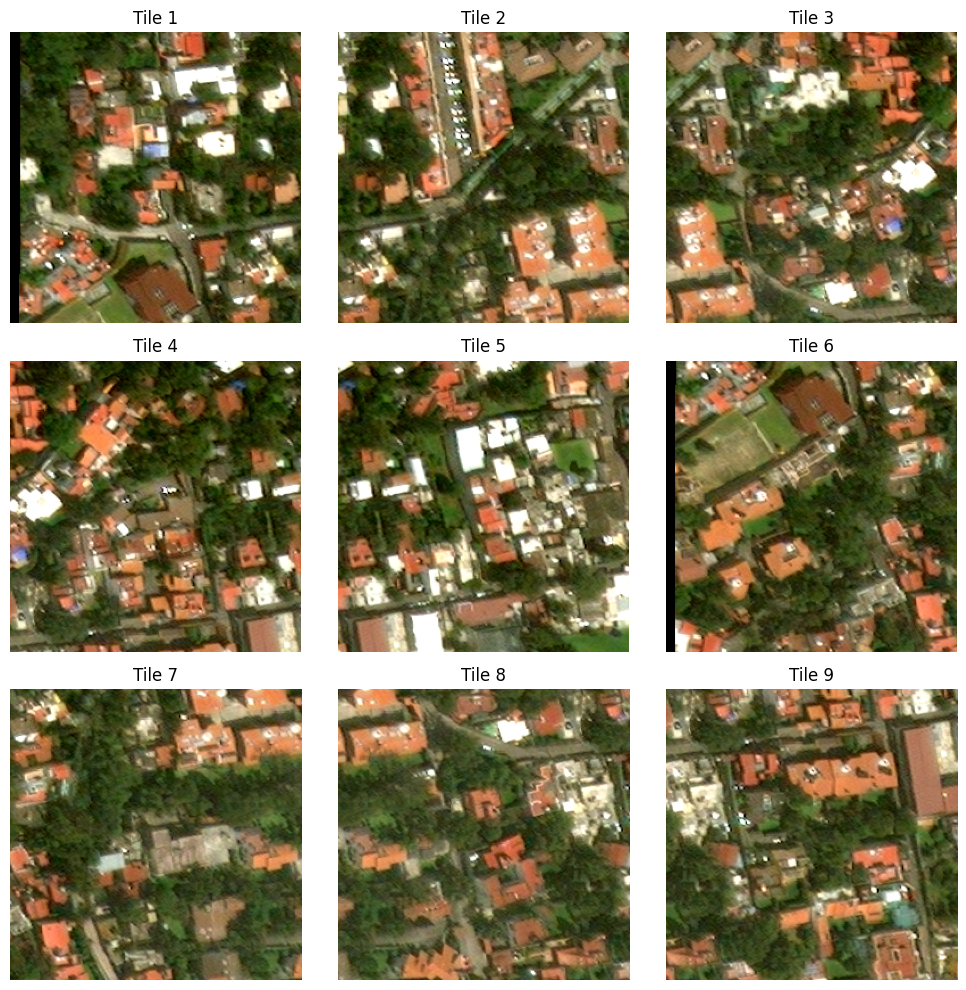

Original image path: /content/drive/MyDrive/12/SP/damage/original/rasterized/rasterized_mexico-earthquake_00000000_post_disaster.tif
Tile size: 256
Number of generated tiles: 25
Shape of the first tile: 65536


TypeError: Invalid shape (1, 256, 256) for image data

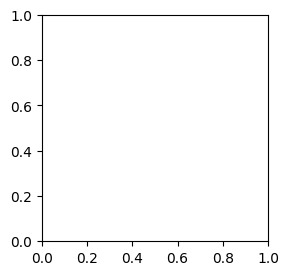

In [9]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import json
import numpy as np

image_path = '/content/drive/MyDrive/12/SP/damage/original/images/mexico-earthquake_00000000_post_disaster.tif'
label_path = '/content/drive/MyDrive/12/SP/damage/original/rasterized/rasterized_mexico-earthquake_00000000_post_disaster.tif'

tile_size = 256 # Define the desired tile size

# Crop the image into tiles
image_tiles = crop_image_into_tiles(image_path, tile_size, is_image = True)

print(f"Original image path: {image_path}")
print(f"Tile size: {tile_size}")
print(f"Number of generated tiles: {len(image_tiles)}")

# Display the shape of the first few tiles
if len(image_tiles) > 0:
    print(f"Shape of the first tile: {image_tiles[0].shape}")
    # Display some of the tiles for visual inspection
    num_tiles_to_display = min(9, len(image_tiles))
    plt.figure(figsize=(10, 10))
    for i in range(num_tiles_to_display):
        plt.subplot(3, 3, i + 1)
        # Transpose tile for matplotlib (C, H, W) -> (H, W, C)
        display_tile = np.transpose(image_tiles[i], (1, 2, 0))
        plt.imshow(display_tile)
        plt.title(f'Tile {i+1}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()


# Crop the image into tiles
label_tiles = crop_image_into_tiles(label_path, tile_size)

print(f"Original image path: {label_path}")
print(f"Tile size: {tile_size}")
print(f"Number of generated tiles: {len(label_tiles)}")

# Display the shape of the first few tiles
if len(label_tiles) > 0:
    print(f"Shape of the first tile: {label_tiles[0].size}")
      #{label_tiles[0].shape}")
    # Display some of the tiles for visual inspection
    num_tiles_to_display = min(9, len(label_tiles))
    plt.figure(figsize=(10, 10))
    for i in range(num_tiles_to_display):
        plt.subplot(3, 3, i + 1)
        # Transpose tile for matplotlib (C, H, W) -> (H, W, C)
        display_tile = label_tiles[i] #np.transpose(label_tiles[i], (1, 2, 0))
        plt.imshow(display_tile)
        plt.title(f'Tile {i+1}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()


In [ ]:
image_dir = '/Users/yujiewu/SP/geotiffs/tier3/images'
label_dir = '/Users/yujiewu/SP/xview2/labels'

tile_size = 256 # Define the desired tile size
use_images = 30
#one image generates 25 tiles

all_image_paths = sorted(glob.glob(os.path.join(image_dir, '*tuscaloosa*.tif')))
all_label_paths = sorted(glob.glob(os.path.join(label_dir, '*tuscaloosa*.tif')))

output_image_dir = '/Users/yujiewu/SP/xview2/cropped/images'
output_label_dir = '/Users/yujiewu/SP/xview2/cropped/labels'

# Ensure output directories exist BEFORE starting to write any files
os.makedirs(output_image_dir, exist_ok=True)
os.makedirs(output_label_dir, exist_ok=True)
print(len(all_image_paths))

for i_image_path, image_path in enumerate(all_image_paths): # Changed loop variable to avoid conflict
  if i_image_path < use_images:
    image_id = get_filename_without_extension(image_path)
    # Crop the image into tiles
    image_tiles = crop_image_into_tiles(image_path, tile_size)
    # os.makedirs(output_image_dir, exist_ok=True) # No longer needed here as it's done at the top
    # Get metadata from the original image for saving tiles
    with rasterio.open(image_path) as src_img:
      img_profile = src_img.profile

    if 'blockxsize' in img_profile: del img_profile['blockxsize']
    if 'blockysize' in img_profile: del img_profile['blockysize']
    if 'tiled' in img_profile: del img_profile['tiled'] # Remove tiled option if it exists
    # Update profiles for individual tiles (assuming the tiles are 256x256 and have the same band count)
    img_profile.update(
        height=tile_size,
        width=tile_size,
        transform=rasterio.transform.from_origin(0, 0, 1, 1) # Simplified transform for saving individual tiles
    )

    for i_image_tile, image_tile in enumerate(image_tiles): # Changed loop variable
      # Ensure tile has correct dimensions before saving
      if image_tile.shape[1] == tile_size and image_tile.shape[2] == tile_size:
          output_filename = os.path.join(output_image_dir, f'{image_id}_{i_image_tile:04d}.tif')
          with rasterio.open(output_filename, 'w', **img_profile) as dst:
              dst.write(image_tile)
      else:
          print(f"Skipping image tile {i_image_tile} due to irregular shape: {image_tile.shape}")

# FOR TIF LABELS
for i_label_path, label_path in enumerate(all_label_paths): # Changed loop variable
  if i_label_path < use_images:
    label_id = get_filename_without_extension(label_path)
    label_tiles = crop_image_into_tiles(label_path, tile_size)
    # os.makedirs(output_label_dir, exist_ok=True) # No longer needed here as it's done at the top

    with rasterio.open(label_path) as src_label:
        label_profile = src_label.profile

    # Remove tiling specific parameters that cause warnings if not explicitly tiling
    # These parameters are often inherited from the source image's profile
    if 'blockxsize' in label_profile: del label_profile['blockxsize']
    if 'blockysize' in label_profile: del label_profile['blockysize']
    if 'tiled' in label_profile: del label_profile['tiled'] # Remove tiled option if it exists

    label_profile.update(
        height=tile_size,
        width=tile_size,
        transform=rasterio.transform.from_origin(0, 0, 1, 1)
    )
    for i_label_tile, label_tile in enumerate(label_tiles): # Changed loop variable
      # Ensure tile has correct dimensions before saving
      if label_tile.shape[1] == tile_size and label_tile.shape[2] == tile_size:
          output_filename = os.path.join(output_label_dir, f'{label_id}_{i_label_tile:04d}.tif')
          with rasterio.open(output_filename, 'w', **label_profile) as dst:
              dst.write(label_tile)
      else:
          print(f"Skipping label tile {i_label_tile} due to irregular shape: {label_tile.shape}")

'''
'''
'''
#FOR PNG LABELS
for i_label_path, label_path in enumerate(all_label_paths): # Changed loop variable
  if i_label_path < use_images:
    label_id = get_filename_without_extension(label_path)
    label_tiles = crop_image_into_tiles(label_path, tile_size)
    # os.makedirs(output_label_dir, exist_ok=True) # No longer needed here as it's done at the top

    with rasterio.open(label_path) as src_label:
        label_profile = src_label.profile

    # Remove tiling specific parameters that cause warnings if not explicitly tiling
    # These parameters are often inherited from the source image's profile
    if 'blockxsize' in label_profile: del label_profile['blockxsize']
    if 'blockysize' in label_profile: del label_profile['blockysize']
    if 'tiled' in label_profile: del label_profile['tiled'] # Remove tiled option if it exists

    # Update profile to reflect a single-band uint8 image, which is common for masks
    label_profile.update(
        count=1, # One band for grayscale mask
        dtype='uint8',
        height=tile_size,
        width=tile_size,
        transform=rasterio.transform.from_origin(0, 0, 1, 1)
    )
    for i_label_tile, label_tile in enumerate(label_tiles): # Changed loop variable
      # Ensure tile has correct dimensions before saving
      if label_tile.size[0] == tile_size and label_tile.size[1] == tile_size:
          # Convert PIL Image to NumPy array and add a channel dimension
          label_tile_np = np.array(label_tile, dtype=np.uint8)[np.newaxis, :, :]
          output_filename = os.path.join(output_label_dir, f'{label_id}_{i_label_tile:04d}.tif')
          with rasterio.open(output_filename, 'w', **label_profile) as dst:
              dst.write(label_tile_np)
      else:
          print(f"Skipping label tile {i_label_tile} due to irregular shape: {label_tile.shape}")

'''
print(f"Saved {len([name for name in os.listdir(output_image_dir) if os.path.isfile(os.path.join(output_image_dir, name))])} image tiles to {output_image_dir}")
print(f"Saved {len([name for name in os.listdir(output_label_dir) if os.path.isfile(os.path.join(output_label_dir, name))])} label tiles to {output_label_dir}")

686
Saved 750 image tiles to /Users/yujiewu/SP/xview2/cropped/images
Saved 750 label tiles to /Users/yujiewu/SP/xview2/cropped/labels


In [10]:
import numpy as np
from PIL import Image
import rasterio
from rasterio.transform import from_origin

def convert_color_png_to_grayscale_tiff(png_path, tiff_output_path):
    """
    Converts a color PNG label mask into a single-band grayscale GeoTIFF,
    mapping each unique color to a unique integer class label.

    Args:
        png_path (str): Path to the input color PNG image.
        tiff_output_path (str): Path to save the output grayscale GeoTIFF.
    """
    print(f"Processing PNG: {png_path}")
    try:
        # 1. Load the PNG image using PIL
        pil_image = Image.open(png_path)
        pil_image = pil_image.convert('RGB') # Ensure it's in RGB mode
        img_np = np.array(pil_image) # Convert to NumPy array

        if img_np.ndim != 3 or img_np.shape[2] not in [3, 4]:
            raise ValueError(f"Input PNG is not a valid RGB/RGBA image: {img_np.shape}")

        height, width, _ = img_np.shape

        # 2. Reshape to a 2D array where each row is an RGB color tuple
        reshaped_img = img_np.reshape(-1, img_np.shape[-1])

        # 3. Identify unique RGB colors and map them to class labels (0, 1, 2, ...)
        # unique_colors_raw stores the actual RGB tuples
        # class_indices stores the integer label for each pixel in the flattened image
        unique_colors_raw, class_indices = np.unique(reshaped_img, axis=0, return_inverse=True)

        # 4. Reshape the class_indices back to the original image dimensions
        grayscale_mask = class_indices.reshape(height, width).astype(np.uint8)

        # Determine rasterio profile for the output TIFF
        profile = {
            'driver': 'GTiff',
            'height': height,
            'width': width,
            'count': 1,  # Single band for grayscale mask
            'dtype': grayscale_mask.dtype, # Use the dtype from the numpy array
            'crs': 'EPSG:4326',  # Default to WGS84, can be updated if actual CRS is known
            'transform': from_origin(0, 0, 1, 1), # A simple identity transform
            'compress': 'lzw' # Optional: LZW compression
        }

        # 5. Save as GeoTIFF using rasterio
        with rasterio.open(tiff_output_path, 'w', **profile) as dst:
            dst.write(grayscale_mask, 1) # Write the grayscale mask to band 1

        print(f"Successfully converted '{png_path}' to '{tiff_output_path}'.")
        print(f"Found {len(unique_colors_raw)} unique colors mapped to classes 0 to {len(unique_colors_raw) - 1}.")

    except Exception as e:
        print(f"Error converting {png_path}: {e}")

print("Function `convert_color_png_to_grayscale_tiff` defined.")

Function `convert_color_png_to_grayscale_tiff` defined.


In [ ]:
label_path = "/content/drive/MyDrive/12/Senior Project Personal Folder/damage/haiti/haiti-earthquake_post_disaster_target.png"
output_path = "/content/drive/MyDrive/12/Senior Project Personal Folder/damage/haiti/haiti-earthquake_post_disaster_target_recoded.tif"
convert_color_png_to_grayscale_tiff(label_path,output_path)

In [ ]:
output_image_dir = '/content/drive/MyDrive/12/Senior Project Personal Folder/xview2/cropped/images/'

#analyze data

Analyzing class distribution across training masks...
Finished analyzing class distribution.
Overall pixel counts per class: Counter({np.int64(4): np.int64(344978138), np.int64(0): np.int64(11483127), np.int64(1): np.int64(1763350), np.int64(3): np.int64(803390), np.int64(2): np.int64(633563)})
[np.int64(11483127), np.int64(1763350), np.int64(633563), np.int64(803390), np.int64(344978138)]


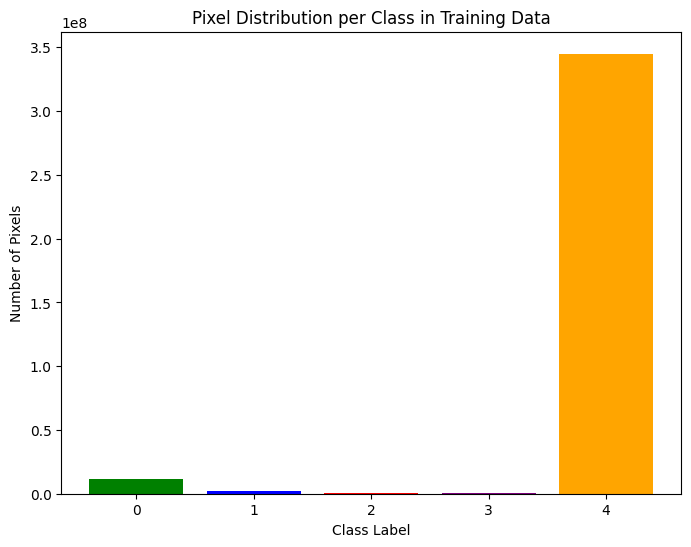

In [13]:
################################################################################
#
#    Don't run more than once after changing dataset size !!!!!!!!!
#
################################################################################


import torch
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

# Get the dataloaders, but we'll primarily use the dataset directly
# to avoid batching complications for this analysis.
# We will use a batch_size of 1 here to easily access individual items.
#dataloaders_for_analysis = get_data_loaders(batch_size=1, subset_size=None)
#train_dataset = dataloaders_for_analysis['train'].dataset

image_dir = '/Users/yujiewu/SP/geotiffs/tier3/images'
label_dir = '/Users/yujiewu/SP/xview2/labels'

use_images = 300
#~19s to convert 50 images

all_image_paths = sorted(glob.glob(os.path.join(image_dir, '*tuscaloosa*post_disaster*.tif')))
all_label_paths = sorted(glob.glob(os.path.join(label_dir, '*tuscaloosa*post_disaster*.tif')))
#all_image_paths = ["/content/drive/MyDrive/12/SP/damage/haiti/haiti-earthquake_post_disaster.tif"]
#all_label_paths = ["/content/drive/MyDrive/12/SP/damage/haiti/haiti-earthquake_post_disaster_target_recoded.tif"]

class_pixel_counts = Counter()
num_classes = 5# train_dataset.num_classes

print(f"Analyzing class distribution across training masks...")

for i in range(len(all_image_paths)):
    # Get the raw mask (before any one-hot encoding or resizing for model input)
    # We need to access the raw mask from the dataset directly or from its path
    # The getitem method returns image_tensor, mask_one_hot
    # We need to load the raw mask using load_raw_mask and apply remapping
    label_path = all_label_paths[i]
    mask_np_raw = load_raw_mask(label_path)

    # Flatten the mask and update the counter
    unique_labels, counts = np.unique(mask_np_raw, return_counts=True)
    class_pixel_counts.update(dict(zip(unique_labels, counts)))

print("Finished analyzing class distribution.")
print("Overall pixel counts per class:", class_pixel_counts)

# Prepare data for plotting
class_labels = sorted(class_pixel_counts.keys())
pixel_counts = [class_pixel_counts[label] for label in class_labels]
print(pixel_counts)
# Create a bar chart for class distribution
plt.figure(figsize=(8, 6))
plt.bar([str(l) for l in class_labels], pixel_counts, color=['green', 'blue', 'red', 'purple', 'orange', 'brown'][:num_classes])
plt.xlabel('Class Label')
plt.ylabel('Number of Pixels')
plt.title('Pixel Distribution per Class in Training Data')
plt.show()



#undersampling stuff

In [14]:

def contains_minority_class(label_path, threshold=0):
    """
    Checks if the percentage of pixels belonging to the minority class (Class 1)
    in a label mask is above a certain threshold.
    """
    mask_np_raw = load_raw_mask(label_path)

    if(threshold == 0):
      return np.any(mask_np_raw == 1) or np.any(mask_np_raw == 2) or np.any(mask_np_raw == 3)

    count_class1 = np.sum(mask_np_raw == 1) + np.sum(mask_np_raw == 2) + np.sum(mask_np_raw == 3)
    total_pixels = mask_np_raw.size

    if total_pixels == 0:
        return False # Avoid division by zero

    percent_class1 = (count_class1 / total_pixels)

    return percent_class1 > threshold

Out of 121
Found 26 samples containing the minority class.
[0, 3, 6, 27, 35, 36, 37, 38, 39, 40, 41, 48, 49, 52, 54, 55, 56, 58, 60, 71, 78, 84, 91, 94, 97, 114]
Displaying 5 random samples with minority class:


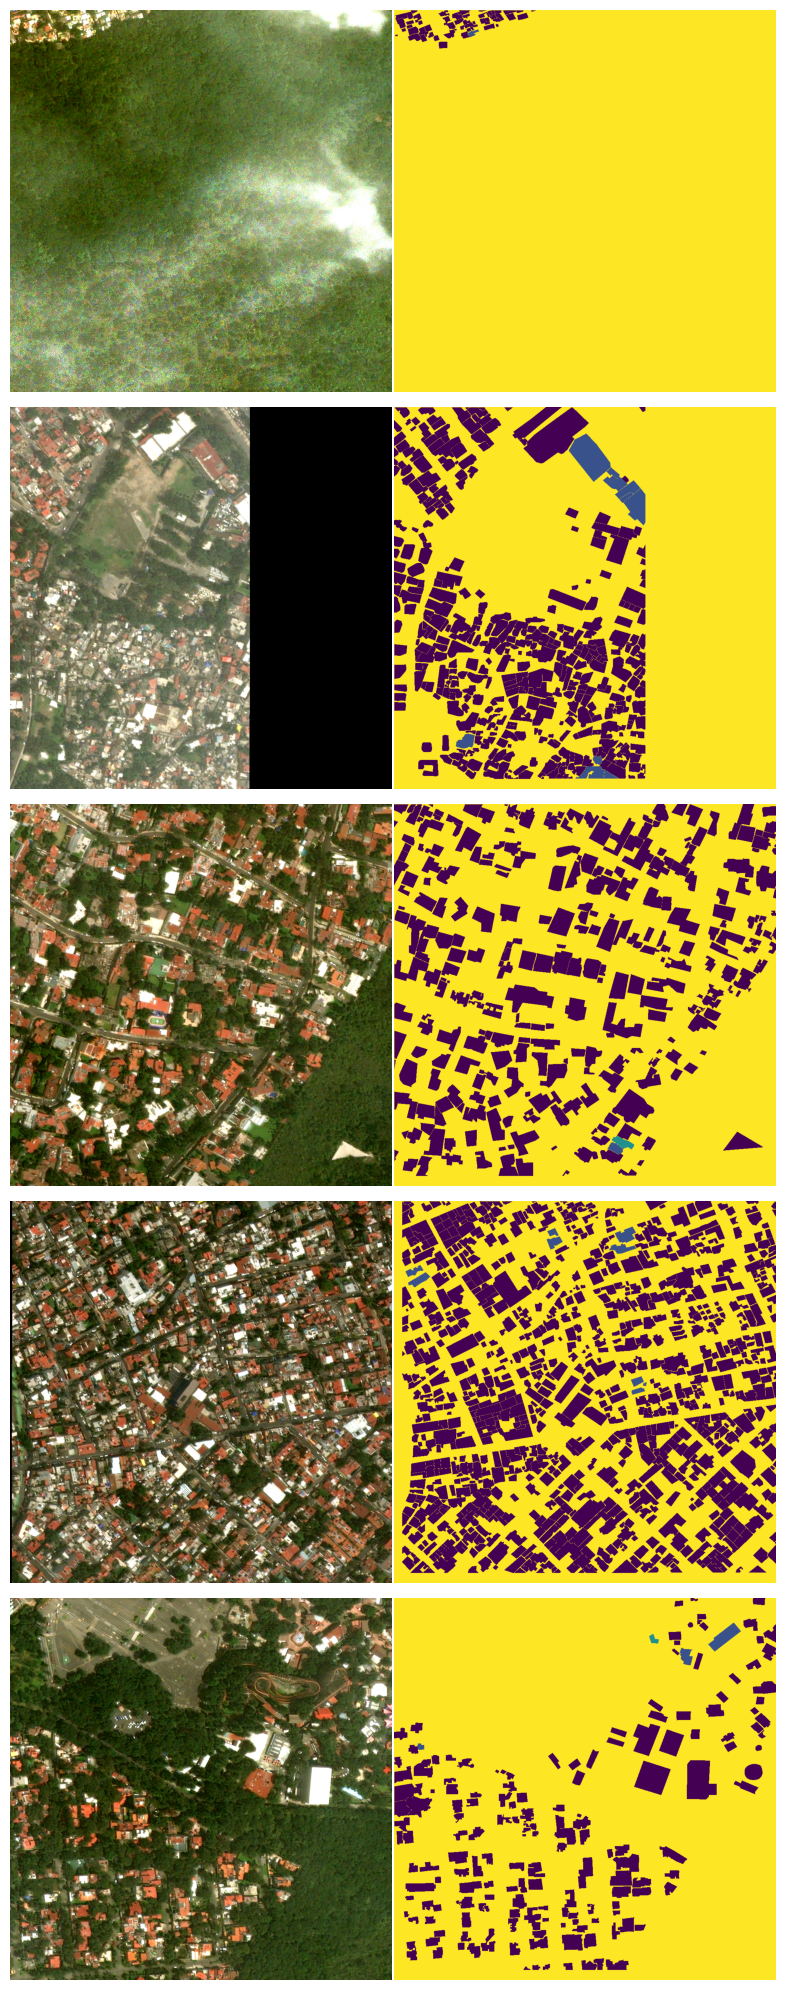

In [23]:
################################################################################
#
#    Don't run more than once after changing dataset size !!!!!!!!!
#
################################################################################
import random
import numpy as np
from functools import reduce # Added for plot_side_by_side
import matplotlib.pyplot as plt # Added for plotting

# Redefine plot_img_array and plot_side_by_side locally to fix the issue
def plot_img_array(img_array, ncol=3):
    nrow = (len(img_array) + ncol - 1) // ncol
    if nrow == 0:
        return

    f, plots = plt.subplots(nrow, ncol, sharex='all', sharey='all', figsize=(ncol * 4, nrow * 4))

    if not isinstance(plots, np.ndarray):
        plots = np.array([plots])
    else:
        plots = plots.ravel()

    for i in range(len(img_array)):
        current_img = img_array[i]
        display_img = current_img

        # Check if the image needs transposing from (C, H, W) to (H, W, C)
        if current_img.ndim == 3:
            if current_img.shape[0] == 3: # RGB image (C, H, W)
                display_img = np.transpose(current_img, (1, 2, 0)) # -> (H, W, C)
            elif current_img.shape[0] == 1: # Grayscale mask (1, H, W)
                display_img = current_img.squeeze(0) # -> (H, W)

        plots[i].imshow(display_img)
        plots[i].axis('off')

    for i in range(len(img_array), len(plots)):
        plots[i].axis('off')

    plt.tight_layout()
    plt.show()

def plot_side_by_side(img_arrays):
    flatten_list = reduce(lambda x,y: x+y, zip(*img_arrays))
    # Fix: remove np.array() which caused ValueError due to inhomogeneous shapes
    plot_img_array(flatten_list, ncol=len(img_arrays))

image_dir = '/Users/yujiewu/SP/geotiffs/tier1/images'
label_dir = '/Users/yujiewu/SP/xview2/labels'

all_image_paths = sorted(glob.glob(os.path.join(image_dir, '*earthquake*post_disaster*.tif')))
all_label_paths = sorted(glob.glob(os.path.join(label_dir, '*earthquake*post_disaster*.tif')))


print(f"Out of {len(all_image_paths)}")
# Collect indices of samples containing the minority class
minority_class_indices = []
for i in range(len(all_image_paths)):
    # We need to load the raw mask and apply remapping as done in contains_minority_class
    # Fixed: Use all_label_paths[i] to check labels for minority class
    label_path = all_label_paths[i]
    if contains_minority_class(label_path, threshold=0):
        minority_class_indices.append(i)

print(f"Found {len(minority_class_indices)} samples containing the minority class.")

print(minority_class_indices)

# Select a random sample of these indices
num_samples_to_display = min(5, len(minority_class_indices)) # Display up to 5 samples
if num_samples_to_display > 0:
    random_indices = random.sample(minority_class_indices, num_samples_to_display)

    input_images_rgb = []
    target_masks_rgb = []

    for idx in random_indices:
        img_tensor = load_and_preprocess(all_image_paths[idx])
        mask_one_hot_tensor = load_raw_mask(all_label_paths[idx])

        # Convert image tensor back to HWC numpy array for visualization
        # Assuming img_tensor is C, H, W and normalized
        input_images_rgb.append(img_tensor)

        # Convert one-hot mask tensor to single-channel class labels for masks_to_colorimg
        # mask_one_hot_tensor is num_classes, H, W. We need to convert it to H, W or 1, H, W
        # masks_to_colorimg expects (num_classes, H, W) where values are probabilities/binary
        # Let's take the argmax to get class labels and then convert to one-hot for masks_to_colorimg
        # Or, simpler, just pass the one_hot_tensor directly if it's already binary/probabilities
        target_masks_rgb.append(mask_one_hot_tensor)

    print(f"Displaying {num_samples_to_display} random samples with minority class:")
    plot_side_by_side([input_images_rgb, target_masks_rgb])
else:
    print("No samples found containing the minority class in the training data.")

In [17]:
#Take all the og images that have a minority class, crop & save them

image_dir = '/Users/yujiewu/SP/geotiffs/tier3/images'
label_dir = '/Users/yujiewu/SP/xview2/labels'

all_image_paths = sorted(glob.glob(os.path.join(image_dir, '*tuscaloosa*post_disaster*.tif')))
all_label_paths = sorted(glob.glob(os.path.join(label_dir, '*tuscaloosa*post_disaster*.tif')))

print(f"Out of {len(all_image_paths)}")
# Collect indices of samples containing the minority class
minority_class_indices = []
for i in range(len(all_image_paths)):
    # We need to load the raw mask and apply remapping as done in contains_minority_class
    # Fixed: Use all_label_paths[i] to check labels for minority class
    label_path = all_label_paths[i]
    if contains_minority_class(label_path, threshold=0.05):
        minority_class_indices.append(i)

print(f"Found {len(minority_class_indices)} samples containing the minority class.")

print(minority_class_indices)

tile_size = 256 # Define the desired tile size
use_images = 30
#one image generates 25 tiles

all_image_paths = sorted(glob.glob(os.path.join(image_dir, '*tuscaloosa*.tif')))
all_label_paths = sorted(glob.glob(os.path.join(label_dir, '*tuscaloosa*.tif')))

output_image_dir = '/Users/yujiewu/SP/xview2/cropped/filter1/images'
output_label_dir = '/Users/yujiewu/SP/xview2/cropped/filter1/labels'

os.makedirs(output_image_dir, exist_ok=True)
os.makedirs(output_label_dir, exist_ok=True)
print(len(all_image_paths))

counter = 0
for i in minority_class_indices:
  counter += 1
  if counter < use_images:
    image_path = all_image_paths[i]
    label_path = all_label_paths[i]

    image_id = get_filename_without_extension(image_path)
    # Crop the image into tiles
    image_tiles = crop_image_into_tiles(image_path, tile_size)

    label_id = get_filename_without_extension(label_path)
    label_tiles = crop_image_into_tiles(label_path, tile_size)

    # os.makedirs(output_image_dir, exist_ok=True) # No longer needed here as it's done at the top
    # Get metadata from the original image for saving tiles
    with rasterio.open(image_path) as src_img:
      img_profile = src_img.profile

    with rasterio.open(label_path) as src_label:
        label_profile = src_label.profile

    if 'blockxsize' in img_profile: del img_profile['blockxsize']
    if 'blockysize' in img_profile: del img_profile['blockysize']
    if 'tiled' in img_profile: del img_profile['tiled'] # Remove tiled option if it exists
    # Update profiles for individual tiles (assuming the tiles are 256x256 and have the same band count)
    img_profile.update(
        height=tile_size,
        width=tile_size,
        transform=rasterio.transform.from_origin(0, 0, 1, 1) # Simplified transform for saving individual tiles
    )

    # Remove tiling specific parameters that cause warnings if not explicitly tiling
    # These parameters are often inherited from the source image's profile
    if 'blockxsize' in label_profile: del label_profile['blockxsize']
    if 'blockysize' in label_profile: del label_profile['blockysize']
    if 'tiled' in label_profile: del label_profile['tiled'] # Remove tiled option if it exists

    label_profile.update(
        height=tile_size,
        width=tile_size,
        transform=rasterio.transform.from_origin(0, 0, 1, 1)
    )

    for i_image_tile, image_tile in enumerate(image_tiles): # Changed loop variable
      # Ensure tile has correct dimensions before saving
      if image_tile.shape[1] == tile_size and image_tile.shape[2] == tile_size:
          output_filename = os.path.join(output_image_dir, f'{image_id}_{i_image_tile:04d}.tif')
          with rasterio.open(output_filename, 'w', **img_profile) as dst:
              dst.write(image_tile)
      else:
          print(f"Skipping image tile {i_image_tile} due to irregular shape: {image_tile.shape}")

    # os.makedirs(output_label_dir, exist_ok=True) # No longer needed here as it's done at the top

    for i_label_tile, label_tile in enumerate(label_tiles): # Changed loop variable
      # Ensure tile has correct dimensions before saving
      if label_tile.shape[1] == tile_size and label_tile.shape[2] == tile_size:
          output_filename = os.path.join(output_label_dir, f'{label_id}_{i_label_tile:04d}.tif')
          with rasterio.open(output_filename, 'w', **label_profile) as dst:
              dst.write(label_tile)
      else:
          print(f"Skipping label tile {i_label_tile} due to irregular shape: {label_tile.shape}")

print(f"Saved {len([name for name in os.listdir(output_image_dir) if os.path.isfile(os.path.join(output_image_dir, name))])} image tiles to {output_image_dir}")
print(f"Saved {len([name for name in os.listdir(output_label_dir) if os.path.isfile(os.path.join(output_label_dir, name))])} label tiles to {output_label_dir}")



Out of 343
Found 22 samples containing the minority class.
[8, 23, 24, 30, 37, 51, 78, 79, 85, 90, 95, 99, 103, 112, 120, 165, 168, 256, 259, 318, 320, 323]
686
Saved 567 image tiles to /Users/yujiewu/SP/xview2/cropped/filter1/images
Saved 567 label tiles to /Users/yujiewu/SP/xview2/cropped/filter1/labels
